**Módulo 30**

**Agrupamento das sessões de acesso ao Portal Considerando o Comportamento de Acesso a Informações da Data especial, fim de semana, e o Mês**

Neste exercício vamos usar a base [online shoppers purchase intention](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset) de Sakar, C.O., Polat, S.O., Katircioglu, M. et al. Neural Comput & Applic (2018). [Web Link](https://doi.org/10.1007/s00521-018-3523-0).

A base trata de registros de 12.330 sessões de acesso a páginas, cada sessão sendo de um único usuário em um período de 12 meses, para posteriormente estudarmos a relação entre o design da página e o perfil do cliente - "Será que clientes com comportamento de navegação diferentes possuem propensão a compra diferente?"

Nosso objetivo agora é agrupar as sessões de acesso ao portal considerando o comportamento de acesso e informações da data, como a proximidade a uma data especial, fim de semana e o mês.

In [24]:
import pandas as pd

# URL do dataset
dataset_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'

# Carregar o dataset em um DataFrame
df = pd.read_csv(dataset_url)

# Exibir as primeiras 5 linhas do DataFrame
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


**Análise Exploratória dos Dados**

**Análise descritiva das variáveis do escopo**

Dimensão da base:
(12330, 21)

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region      

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64



Valores faltantes:


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue_Numeric,Cluster_3,Cluster_4
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586,0.232603,0.154745,0.780616,0.965369
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169,0.422509,0.361676,0.585296,1.293062
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000,1.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000,1.000000,2.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000,2.000000,3.000000


,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


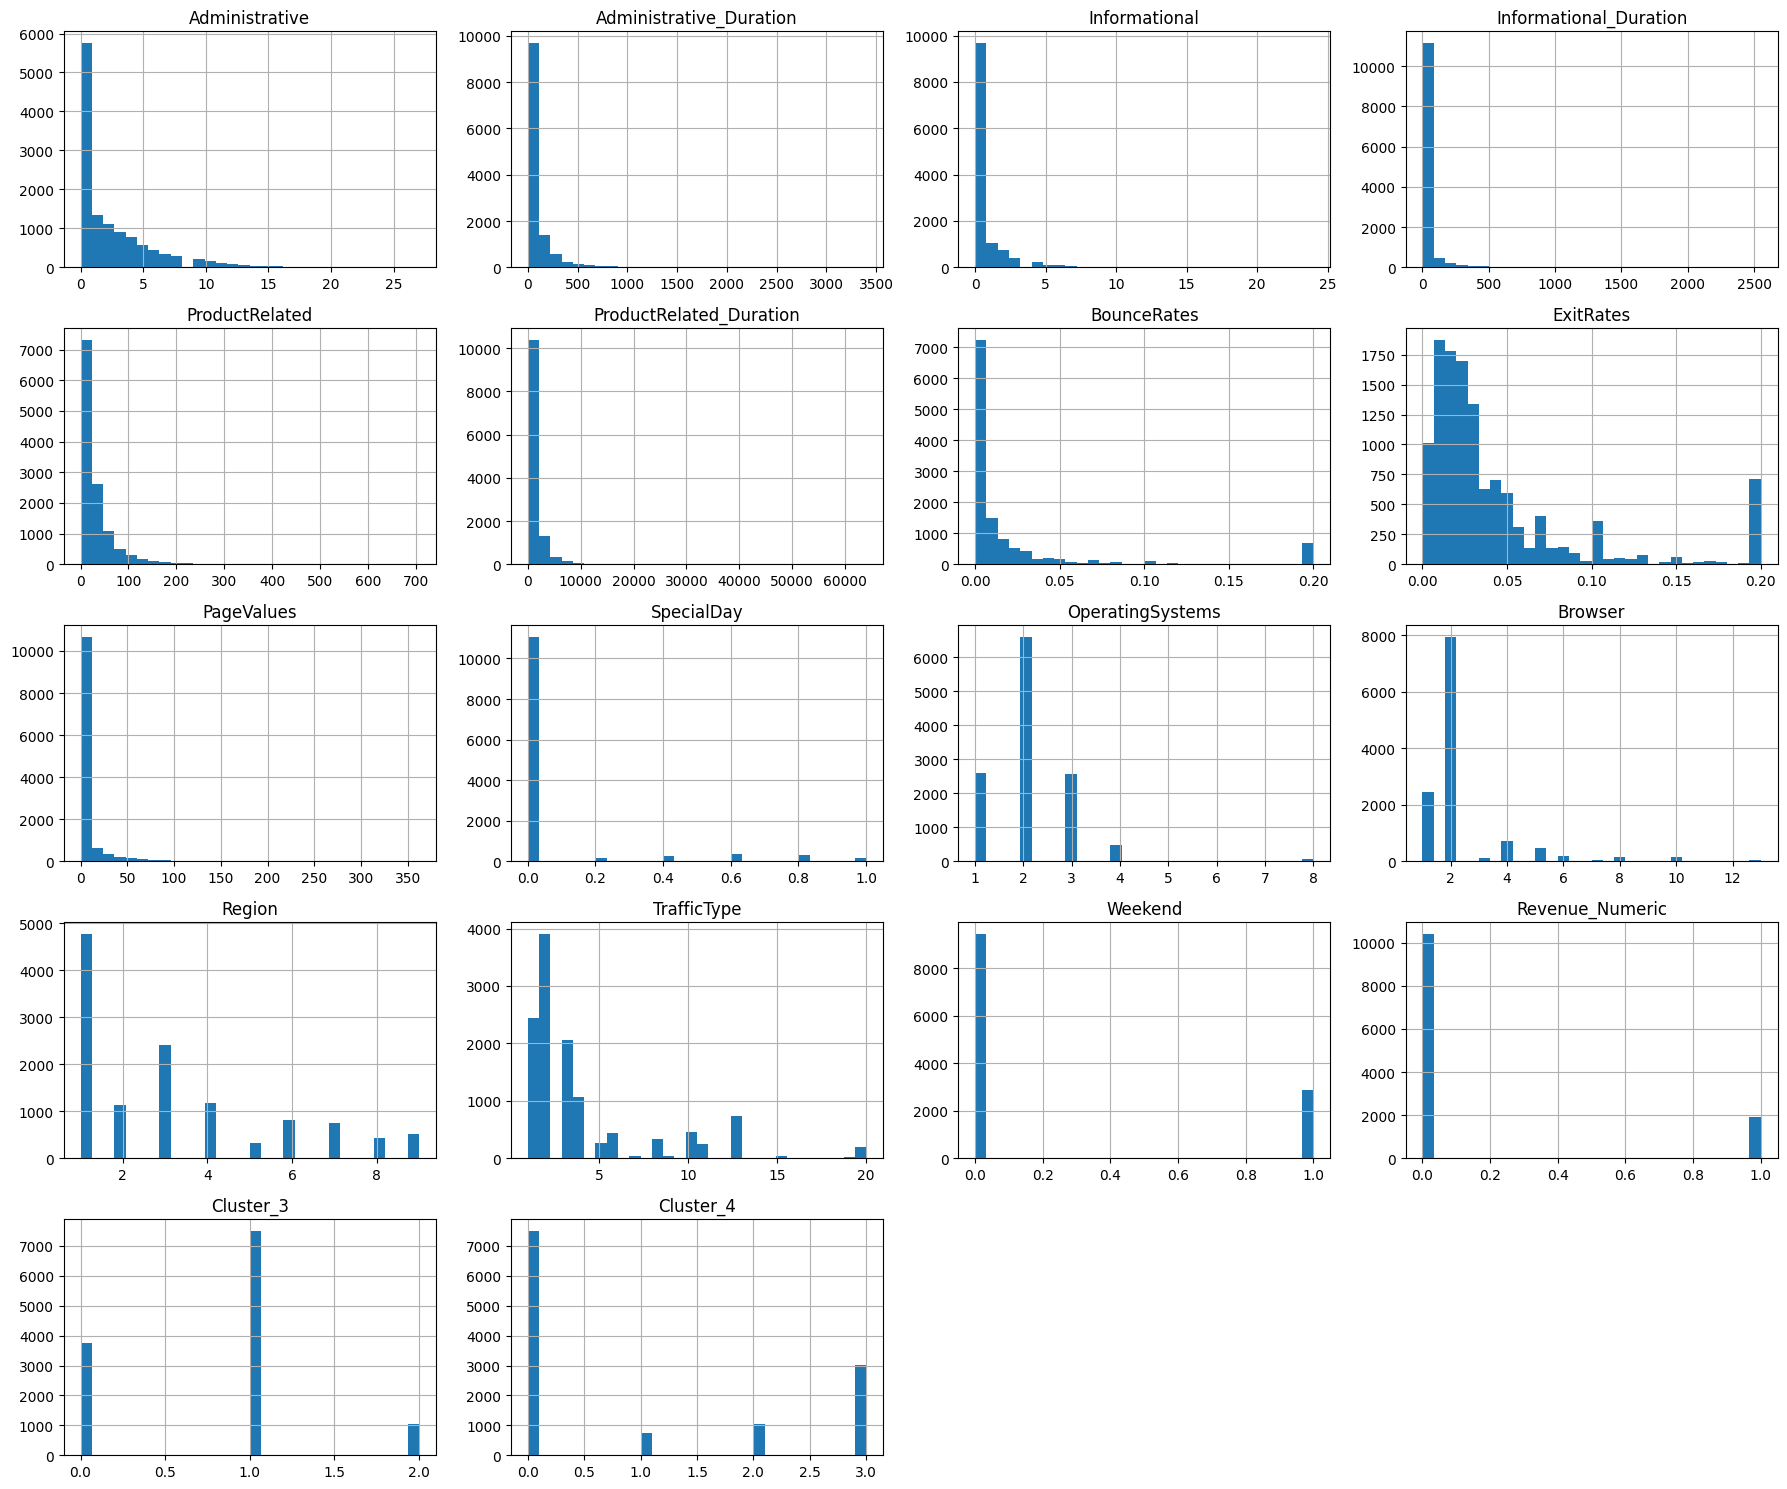

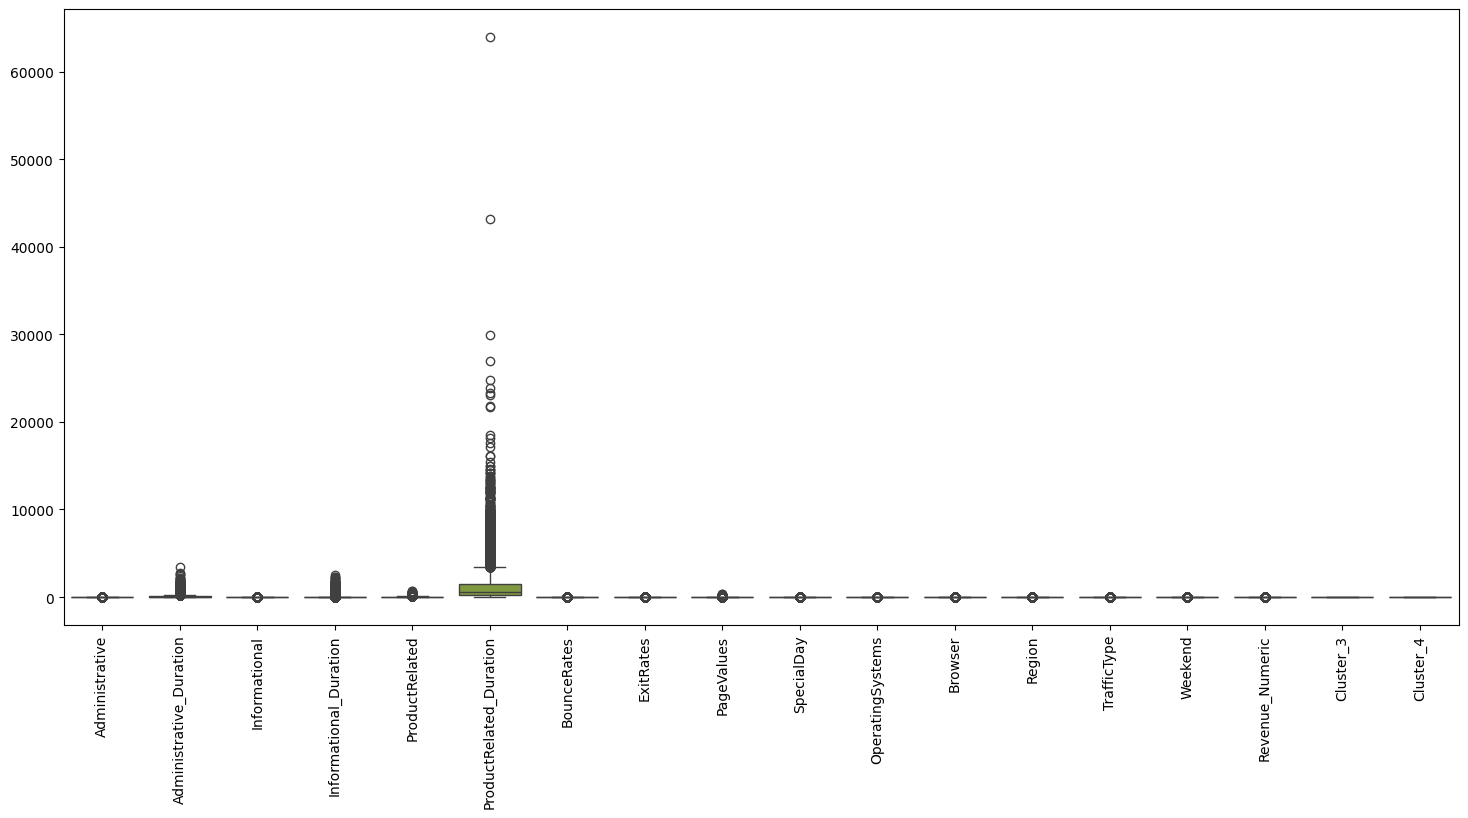

Não foram identificados valores missing na base.


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Verificando estrutura dos dados

print('Dimensão da base:')
print(df.shape)

print('\nInformações gerais do DataFrame:')
df.info()

print('\nTipos das variáveis:')
display(df.dtypes)

print('\nValores faltantes:')
display(df.isnull().sum())

# Estatísticas descritivas
display(df.describe())

# Estatísticas das variáveis categóricas
display(df.describe(include='object'))

# Distribuição das variáveis numéricas

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()
plt.show()

# Boxplots para avaliar outliers

plt.figure(figsize=(18,8))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.show()

print('Não foram identificados valores missing na base.')

**Seleção e preparação das variáveis para agrupamento**

In [85]:
from sklearn.preprocessing import StandardScaler

# Variáveis escolhidas:
# comportamento de navegação
# características da visita
# características temporais

vars_cluster = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'Month',
    'VisitorType',
    'Weekend'
]

cluster = df[vars_cluster].copy()

# Tratamento das categóricas

cluster = pd.get_dummies(
    cluster,
    columns=['Month','VisitorType'],
    drop_first=True
)

# Boolean para inteiro

cluster['Weekend'] = cluster['Weekend'].astype(int)

# Padronização

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster)

print('Dimensão da matriz final:')
print(X_scaled.shape)

Dimensão da matriz final:
(12330, 22)


**Construção dos Agrupamentos e Avaliação dos Grupos:
Agrupamentos hierárquicos com 3 e 4 grupos**

In [86]:
from sklearn.cluster import AgglomerativeClustering

# Modelo com 3 grupos

modelo3 = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df['Cluster_3'] = modelo3.fit_predict(X_scaled)

# Modelo com 4 grupos

modelo4 = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

df['Cluster_4'] = modelo4.fit_predict(X_scaled)

print('Distribuição dos grupos (3 clusters)')
display(df['Cluster_3'].value_counts())

print('Distribuição dos grupos (4 clusters)')
display(df['Cluster_4'].value_counts())

# Perfil dos grupos

print('Perfil dos grupos - solução com 3 clusters')

display(
    df.groupby('Cluster_3')[
        [
            'Administrative',
            'Informational',
            'ProductRelated',
            'PageValues',
            'BounceRates',
            'ExitRates'
        ]
    ].mean()
)

print('Perfil dos grupos - solução com 4 clusters')

display(
    df.groupby('Cluster_4')[
        [
            'Administrative',
            'Informational',
            'ProductRelated',
            'PageValues',
            'BounceRates',
            'ExitRates'
        ]
    ].mean()
)

print('A solução com 4 grupos apresenta maior capacidade de segmentação dos perfis de navegação.')

Distribuição dos grupos (3 clusters)


,count
Cluster_3,
1,7513
0,3761
2,1056


Distribuição dos grupos (4 clusters)


,count
Cluster_4,
0,7513
3,3015
2,1056
1,746


Perfil dos grupos - solução com 3 clusters


,Administrative,Informational,ProductRelated,PageValues,BounceRates,ExitRates
Cluster_3,,,,,,
0,1.446158,0.274395,22.672693,3.292910,0.047473,0.068334
1,2.141355,0.347797,25.851324,6.827398,0.011745,0.033636
2,6.646780,2.428030,105.829545,8.461811,0.006472,0.020243


Perfil dos grupos - solução com 4 clusters


,Administrative,Informational,ProductRelated,PageValues,BounceRates,ExitRates
Cluster_4,,,,,,
0,2.141355,0.347797,25.851324,6.827398,0.011745,0.033636
1,0.151475,0.028150,3.776139,0.219607,0.161679,0.168574
2,6.646780,2.428030,105.829545,8.461811,0.006472,0.020243
3,1.766501,0.335323,27.348259,4.053336,0.019215,0.043532


A solução com 4 grupos apresenta maior capacidade de segmentação dos perfis de navegação.


**Avaliação dos Resultados dos grupos utilizando Bounce Rate e Revenue**

In [63]:
print('Revenue por grupo - 3 clusters')

display(
    pd.crosstab(
        df['Cluster_3'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

print('Bounce Rate médio - 3 clusters')

display(
    df.groupby('Cluster_3')['BounceRates'].mean()
)

print('Revenue por grupo - 4 clusters')

display(
    pd.crosstab(
        df['Cluster_4'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

print('Bounce Rate médio - 4 clusters')

display(
    df.groupby('Cluster_4')['BounceRates'].mean()
)

print("""
O grupo mais propenso à compra é aquele que apresenta:
- Maior percentual de Revenue = True
- Menor Bounce Rate
- Maior PageValues
- Maior quantidade de páginas de produtos visitadas

A solução com 4 grupos apresentou segmentação mais detalhada dos usuários,
sendo a opção escolhida para análise final.
""")

Revenue por grupo - 3 clusters


Revenue,False,True
Cluster_3,,
0,92.182930,7.817070
1,83.375482,16.624518
2,65.435606,34.564394


Bounce Rate médio - 3 clusters


,BounceRates
Cluster_3,
0,0.047473
1,0.011745
2,0.006472


Revenue por grupo - 4 clusters


Revenue,False,True
Cluster_4,,
0,83.375482,16.624518
1,99.329759,0.670241
2,65.435606,34.564394
3,90.414594,9.585406


Bounce Rate médio - 4 clusters


,BounceRates
Cluster_4,
0,0.011745
1,0.161679
2,0.006472
3,0.019215



O grupo mais propenso à compra é aquele que apresenta:
- Maior percentual de Revenue = True
- Menor Bounce Rate
- Maior PageValues
- Maior quantidade de páginas de produtos visitadas

A solução com 4 grupos apresentou segmentação mais detalhada dos usuários,
sendo a opção escolhida para análise final.



### Análise dos Clusters em Relação a `SpecialDay`, `Weekend` e `Month`

Vamos analisar como os clusters se comportam em relação a datas especiais, dias da semana e meses do ano, para entender melhor o perfil temporal de cada grupo.

In [64]:
import pandas as pd

# Convert 'Weekend' to int for mean calculation if not already
if df['Weekend'].dtype == 'bool':
    df['Weekend_Numeric'] = df['Weekend'].astype(int)
else:
    df['Weekend_Numeric'] = df['Weekend']

print('Média de SpecialDay e Weekend por grupo - 3 clusters')
display(
    df.groupby('Cluster_3')[['SpecialDay', 'Weekend_Numeric']].mean()
)

print('Média de SpecialDay e Weekend por grupo - 4 clusters')
display(
    df.groupby('Cluster_4')[['SpecialDay', 'Weekend_Numeric']].mean()
)

Média de SpecialDay e Weekend por grupo - 3 clusters


,SpecialDay,Weekend_Numeric
Cluster_3,,
0,0.192715,0.198352
1,0.003328,0.240650
2,0.007197,0.297348


Média de SpecialDay e Weekend por grupo - 4 clusters


,SpecialDay,Weekend_Numeric
Cluster_4,,
0,0.003328,0.240650
1,0.067024,0.170241
2,0.007197,0.297348
3,0.223814,0.205307


In [65]:
import pandas as pd

# Create dummy variables for 'Month' directly from df for this analysis
df_month_dummies_eval = pd.get_dummies(df['Month'], prefix='Month')

# Concatenate with the original DataFrame to include cluster assignments
df_with_month_dummies = pd.concat([df, df_month_dummies_eval], axis=1)

# Identify the one-hot encoded month columns
month_cols = [col for col in df_with_month_dummies.columns if col.startswith('Month_')]

print('Prevalência de Mês por grupo - 3 clusters (em %)')
display(
    df_with_month_dummies.groupby('Cluster_3')[month_cols].mean() * 100 # Display as percentage
)

print('Prevalência de Mês por grupo - 4 clusters (em %)')
display(
    df_with_month_dummies.groupby('Cluster_4')[month_cols].mean() * 100 # Display as percentage
)

Prevalência de Mês por grupo - 3 clusters (em %)


,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
Cluster_3,,,,,,,,,,
0,8.029779,2.446158,4.892316,0.000000,0.000000,3.509705,77.160330,3.961712,0.000000,0.000000
1,1.118062,21.030214,0.000000,5.656861,3.833356,22.946892,4.152802,28.244376,7.134301,5.883136
2,4.450758,5.208333,0.000000,0.662879,0.000000,4.829545,14.204545,68.844697,1.231061,0.568182


Prevalência de Mês por grupo - 4 clusters (em %)


,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
Cluster_4,,,,,,,,,,
0,1.118062,21.030214,0.000000,5.656861,3.833356,22.946892,4.152802,28.244376,7.134301,5.883136
1,1.876676,12.332440,24.664879,0.000000,0.000000,17.694370,23.458445,19.973190,0.000000,0.000000
2,4.450758,5.208333,0.000000,0.662879,0.000000,4.829545,14.204545,68.844697,1.231061,0.568182
3,9.552239,0.000000,0.000000,0.000000,0.000000,0.000000,90.447761,0.000000,0.000000,0.000000


In [26]:
# Converter a coluna 'Revenue' de booleano para numérico (True=1, False=0)
df['Revenue_Numeric'] = df['Revenue'].astype(int)

# Selecionar apenas as colunas numéricas para o cálculo da correlação
numeric_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numeric_cols].corr()

# Exibir a correlação com a coluna 'Revenue_Numeric' em ordem descendente
revenue_correlations = correlation_matrix['Revenue_Numeric'].sort_values(ascending=False)
display(revenue_correlations)

,Revenue_Numeric
Revenue_Numeric,1.000000
PageValues,0.492569
ProductRelated,0.158538
ProductRelated_Duration,0.152373
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
Informational_Duration,0.070345
Browser,0.023984
TrafficType,-0.005113


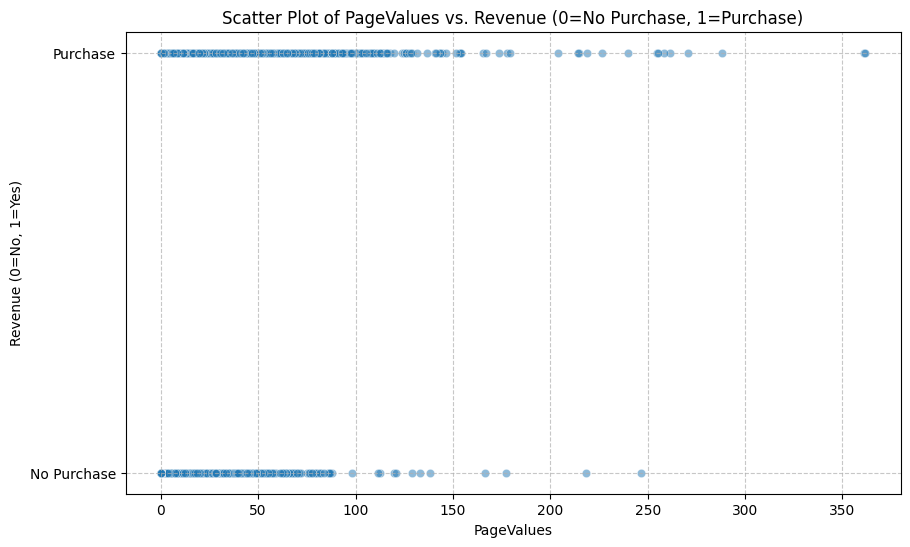

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PageValues', y='Revenue_Numeric', data=df, alpha=0.5)
plt.title('Scatter Plot of PageValues vs. Revenue (0=No Purchase, 1=Purchase)')
plt.xlabel('PageValues')
plt.ylabel('Revenue (0=No, 1=Yes)')
plt.yticks([0, 1], ['No Purchase', 'Purchase']) # Improve y-axis labels for clarity
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Preparação dos Dados para o Modelo de Classificação

Primeiro, vamos preparar os dados para o modelo de classificação, o que inclui:

1.  Converter a coluna booleana 'Weekend' para numérica (0 ou 1).
2.  Aplicar One-Hot Encoding às colunas categóricas 'Month' e 'VisitorType'.
3.  Separar as features (X) do target (y).
4.  Dividir o dataset em conjuntos de treino e teste.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Convert 'Weekend' from boolean to int
df['Weekend'] = df['Weekend'].astype(int)

# Handle categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Drop the original 'Revenue' column as we have 'Revenue_Numeric'
# and other original categorical columns that were encoded.
df_encoded = df_encoded.drop(columns=['Revenue'])

# Define features (X) and target (y)
X = df_encoded.drop(columns=['Revenue_Numeric'])
y = df_encoded['Revenue_Numeric']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (8631, 26)
Shape of X_test: (3699, 26)
Shape of y_train: (8631,)
Shape of y_test: (3699,)


## Treinamento e Avaliação do Modelo de Classificação


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8991619356582861

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      3127
           1       0.74      0.54      0.62       572

    accuracy                           0.90      3699
   macro avg       0.83      0.75      0.78      3699
weighted avg       0.89      0.90      0.89      3699


Confusion Matrix:
 [[3016  111]
 [ 262  310]]


## Análise de Importância das Features


### Melhorando o Recall para a Classe de Compra (Classe 1) com SMOTE



In [37]:
# Instalar a biblioteca imbalanced-learn se ainda não estiver instalada
!pip install imbalanced-learn

In [38]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original class distribution: {Counter(y_train)}")

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = sm.fit_resample(X_train, y_train)

print(f"Resampled class distribution (SMOTE): {Counter(y_resampled_smote)}")

Original class distribution: Counter({0: 7295, 1: 1336})
Resampled class distribution (SMOTE): Counter({0: 7295, 1: 7295})


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the RandomForestClassifier with SMOTE resampled data
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_resampled_smote, y_resampled_smote)

# Make predictions on the original test set
y_pred_smote = model_smote.predict(X_test)

# Evaluate the model with SMOTE resampled data
print("Accuracy (with SMOTE):", accuracy_score(y_test, y_pred_smote))
print("\nClassification Report (with SMOTE):\n", classification_report(y_test, y_pred_smote))
print("\nConfusion Matrix (with SMOTE):\n", confusion_matrix(y_test, y_pred_smote))

Accuracy (with SMOTE): 0.8867261422005948

Classification Report (with SMOTE):
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      3127
           1       0.62      0.70      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.81      0.79      3699
weighted avg       0.89      0.89      0.89      3699


Confusion Matrix (with SMOTE):
 [[2880  247]
 [ 172  400]]


### Ajuste de Hiperparâmetros do Random Forest com GridSearchCV


In [47]:
from sklearn.model_selection import GridSearchCV

# Definir uma grade de parâmetros simplificada para testes mais rápidos
param_grid_simplified = {
    'n_estimators': [100, 200],  # Reduzido para 2 valores
    'max_depth': [10, 20, None],  # Reduzido para 3 valores
    'min_samples_split': [5, 10], # Reduzido para 2 valores
    'min_samples_leaf': [2, 4],   # Reduzido para 2 valores
    'criterion': ['gini']         # Reduzido para 1 valor
}

# Inicializar o GridSearchCV com a grade simplificada
grid_search_simplified = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_simplified,
    cv=2,  # Reduzindo para 2 folds para maior velocidade
    n_jobs=-1,  # Usar todos os núcleos do processador disponíveis
    verbose=2,  # Detalhes do processo
    scoring='recall' # Focar no recall para a classe minoritária
)

# Executar a busca na grade usando os dados de treinamento balanceados pelo SMOTE
grid_search_simplified.fit(X_resampled_smote, y_resampled_smote)

# Exibir os melhores parâmetros e a melhor pontuação da busca simplificada
print("Melhores parâmetros encontrados (simplificado):", grid_search_simplified.best_params_)
print("Melhor recall (validação cruzada, simplificado):", grid_search_simplified.best_score_)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
Melhores parâmetros encontrados (simplificado): {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Melhor recall (validação cruzada, simplificado): 0.9361144659272942


Com os melhores hiperparâmetros identificados, vamos treinar o modelo final e avaliar seu desempenho no conjunto de teste original.

In [50]:
# Obter o melhor modelo da busca em grade simplificada
best_rf_model = grid_search_simplified.best_estimator_

# Fazer previsões no conjunto de teste original
y_pred_tuned = best_rf_model.predict(X_test)

# Avaliar o modelo otimizado
print("Accuracy (modelo otimizado):", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report (modelo otimizado):\n", classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix (modelo otimizado):\n", confusion_matrix(y_test, y_pred_tuned))

Accuracy (modelo otimizado): 0.8867261422005948

Classification Report (modelo otimizado):
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      3127
           1       0.62      0.71      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.82      0.80      3699
weighted avg       0.89      0.89      0.89      3699


Confusion Matrix (modelo otimizado):
 [[2872  255]
 [ 164  408]]


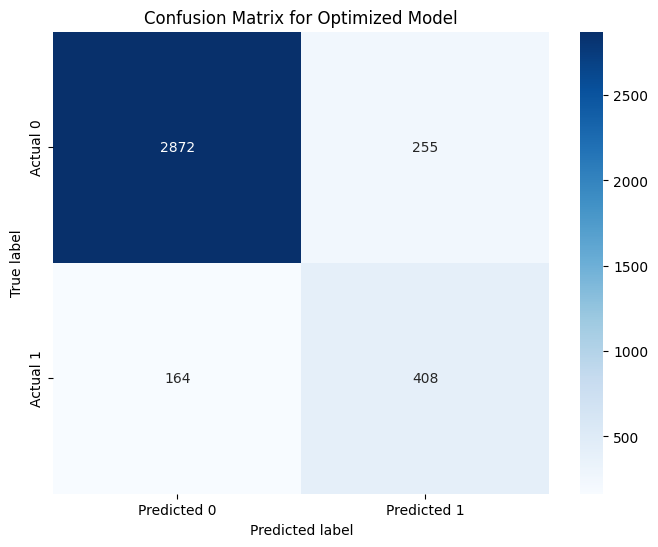

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the optimized model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Optimized Model')
plt.show()

In [52]:
import numpy as np
from sklearn.metrics import classification_report

# Obter as probabilidades previstas para o conjunto de teste
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Definir um novo limiar de classificação
new_threshold = 0.7

# Gerar previsões com base no novo limiar
y_pred_tuned_high_threshold = (y_pred_proba >= new_threshold).astype(int)

# Avaliar o modelo com o novo limiar
print(f"Classification Report (Modelo Otimizado com Limiar={new_threshold}):\n",
      classification_report(y_test, y_pred_tuned_high_threshold))

Classification Report (Modelo Otimizado com Limiar=0.7):
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      3127
           1       0.70      0.55      0.62       572

    accuracy                           0.89      3699
   macro avg       0.81      0.75      0.78      3699
weighted avg       0.89      0.89      0.89      3699



**Preparação dos Dados para Clusterização**


### Comparação das Métricas com Diferentes Limiares

Analise e comparação dos resultados do modelo otimizado com os limiares de classificação de 0.5 (padrão) e 0.7 para a classe 'Purchase' (classe 1).

**Modelo Otimizado (Limiar Padrão = 0.5):**

```
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      3127
           1       0.62      0.71      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.82      0.80      3699
weighted avg       0.89      0.89      0.89      3699
```

**Modelo Otimizado (Limiar Ajustado = 0.7):**

```
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      3127
           1       0.70      0.55      0.62       572

    accuracy                           0.89      3699
   macro avg       0.81      0.75      0.78      3699
weighted avg       0.89      0.89      0.89      3699
```

**Análise Comparativa:**

*   **Precisão (Classe 1 - Compra):**
    *   Limiar 0.5: 0.62
    *   Limiar 0.7: 0.70 (Aumento significativo)
    
    Com o limiar de 0.7, a precisão da classe 'Compra' aumentou de 62% para 70%. Isso significa que, quando o modelo prevê uma compra com este limiar, ele está mais correto.

*   **Recall (Classe 1 - Compra):**
    *   Limiar 0.5: 0.71
    *   Limiar 0.7: 0.55 (Redução significativa)
    
    Em contrapartida, o recall da classe 'Compra' diminuiu de 71% para 55%. Isso indica que o modelo está identificando menos das compras reais, classificando mais compras como 'não compras' para atingir a maior precisão.

*   **Accuracy:** Permaneceu em 0.89 para ambos os limiares, mostrando que o ajuste do limiar afeta o balanço entre precisão e recall para a classe minoritária, mas não a acurácia geral do modelo.

**Decisão:**

A escolha do melhor limiar depende do objetivo de negócio:

*   **Se for mais importante minimizar falsos positivos (ou seja, ter certeza de que uma previsão de compra é realmente uma compra)**, o **limiar de 0.7** é preferível, pois oferece uma precisão mais alta para a classe 1.
*   **Se for mais importante identificar o maior número possível de compras reais, mesmo que isso signifique mais falsos positivos**, o **limiar padrão de 0.5** (ou um limiar ainda menor) pode ser mais adequado devido ao seu recall mais alto.

### Otimizando o Limiar com a Curva Precision-Recall

Para otimizar o limiar e encontrar o melhor equilíbrio entre precisão e recall, podemos utilizar a curva Precision-Recall. Esta curva plota a precisão versus o recall para diferentes limiares de classificação. Analisando a curva, podemos escolher um limiar que atenda aos objetivos específicos do negócio – seja priorizando uma alta precisão para minimizar falsos positivos, ou um alto recall para capturar o máximo de verdadeiros positivos.

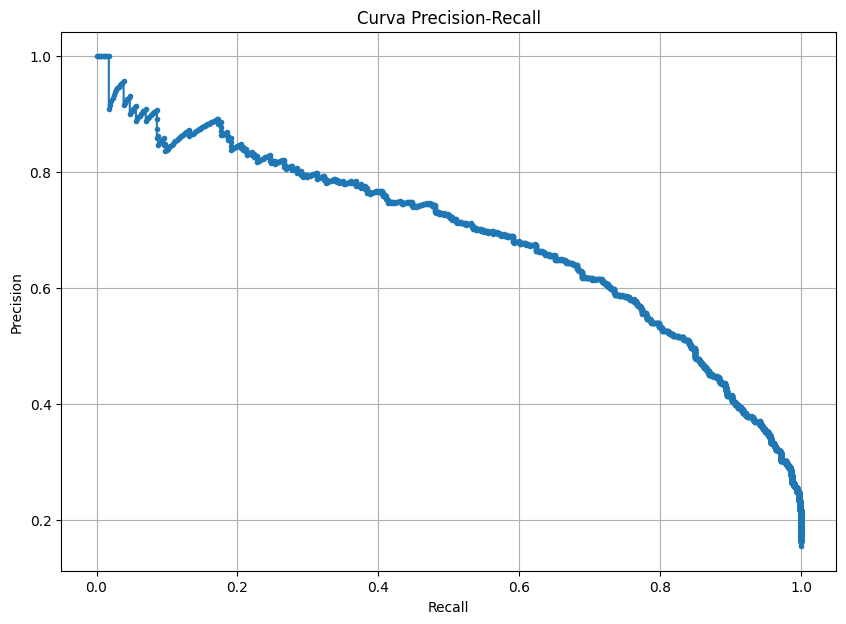

In [53]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Obter as probabilidades previstas para o conjunto de teste (já calculado anteriormente)
# y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular precisão e recall para vários limiares
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Encontrar o limiar onde a precisão e o recall estão mais próximos (opcional, como um ponto de partida)
# F-score = 2 * (precision * recall) / (precision + recall)
# fscore = (2 * precision * recall) / (precision + recall)
# ix = np.argmax(fscore)
# print('Best Threshold=%f, F-Score=%.3f' % (thresholds[ix], fscore[ix]))

# Plotar a curva Precision-Recall
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

### Como Interpretar a Curva Precision-Recall

*   **O Eixo X (Recall)**: Representa a proporção de verdadeiros positivos que foram corretamente identificados.
*   **O Eixo Y (Precision)**: Representa a proporção de previsões positivas que eram realmente corretas.

**Pontos Chave para Análise:**

*   **Alto Recall e Baixa Precisão**: Significa que o modelo identifica a maioria dos casos positivos, mas também tem muitos falsos positivos.
*   **Alta Precisão e Baixo Recall**: Significa que o modelo é muito conservador em suas previsões positivas, mas pode perder muitos casos positivos reais.
*   **Ponto de Equilíbrio**: O "ponto ideal" na curva depende do custo de falsos positivos versus falsos negativos para o seu problema de negócio. Por exemplo, se é mais crítico não perder nenhum cliente com intenção de compra (alto recall), você pode tolerar um pouco mais de falsos positivos (menor precisão). Se é crucial que uma oferta seja enviada apenas para clientes com alta certeza de compra (alta precisão), você pode aceitar perder alguns potenciais compradores (menor recall).

Você pode inspecionar o gráfico e escolher um ponto na curva que melhor represente o equilíbrio desejado. Para encontrar o limiar correspondente a um ponto específico (precision, recall) no gráfico, você precisaria analisar o array `thresholds` gerado pela função `precision_recall_curve` em conjunto com os arrays `precision` e `recall`.

### Encontrando o Limiar Ótimo Usando F1-Score

Para encontrar um limiar que equilibre precisão e recall vamos maximizar o F1-score. O F1-score é a média harmônica da precisão e do recall, e um valor alto indica um bom equilíbrio entre as duas métricas.

In [54]:
from sklearn.metrics import f1_score

# Calcular F1-scores para cada limiar
# 'thresholds' tem um elemento a menos que 'precision' e 'recall'
fscores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

# Encontrar o limiar que maximiza o F1-score
ix = np.argmax(fscores)
best_threshold_f1 = thresholds[ix]

print(f"Melhor Limiar (Max F1-Score): {best_threshold_f1:.4f}")
print(f"Precisão no Melhor Limiar: {precision[ix]:.4f}")
print(f"Recall no Melhor Limiar: {recall[ix]:.4f}")
print(f"F1-Score Máximo: {fscores[ix]:.4f}")

# Gerar previsões com base no limiar que maximiza o F1-score
y_pred_f1_tuned = (y_pred_proba >= best_threshold_f1).astype(int)

# Avaliar o modelo com o limiar que maximiza o F1-score
print(f"\nClassification Report (Modelo Otimizado com Limiar = {best_threshold_f1:.4f}):\n",
      classification_report(y_test, y_pred_f1_tuned))

Melhor Limiar (Max F1-Score): 0.4958
Precisão no Melhor Limiar: 0.6156
Recall no Melhor Limiar: 0.7168
F1-Score Máximo: 0.6624

Classification Report (Modelo Otimizado com Limiar = 0.4958):
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      3127
           1       0.62      0.72      0.66       572

    accuracy                           0.89      3699
   macro avg       0.78      0.82      0.80      3699
weighted avg       0.90      0.89      0.89      3699



In [55]:
# Exemplo: Encontrar o limiar para uma precisão mínima de 0.75
min_precision_target = 0.75

# Encontrar todos os limiares onde a precisão é maior ou igual ao target
thresholds_for_target_precision = thresholds[precision[:-1] >= min_precision_target]

# Se houver limiares, pegar o menor (que geralmente oferece o melhor recall para essa precisão)
if len(thresholds_for_target_precision) > 0:
    chosen_threshold = thresholds_for_target_precision[0] # Ou um limiar específico da sua escolha

    # Encontrar o índice deste limiar nos arrays originais
    idx = np.where(thresholds == chosen_threshold)[0][0]

    print(f"\nPara uma precisão mínima de {min_precision_target}:")
    print(f"Limiar escolhido: {chosen_threshold:.4f}")
    print(f"Precisão correspondente: {precision[idx]:.4f}")
    print(f"Recall correspondente: {recall[idx]:.4f}")

    # Avaliar o modelo com o limiar escolhido manualmente
    y_pred_manual_tuned = (y_pred_proba >= chosen_threshold).astype(int)
    print(f"\nClassification Report (Modelo Otimizado com Limiar = {chosen_threshold:.4f}):\n",
          classification_report(y_test, y_pred_manual_tuned))
else:
    print(f"Nenhum limiar encontrado para uma precisão mínima de {min_precision_target}.")


Para uma precisão mínima de 0.75:
Limiar escolhido: 0.7758
Precisão correspondente: 0.7500
Recall correspondente: 0.4301

Classification Report (Modelo Otimizado com Limiar = 0.7758):
               precision    recall  f1-score   support

           0       0.90      0.97      0.94      3127
           1       0.75      0.43      0.55       572

    accuracy                           0.89      3699
   macro avg       0.83      0.70      0.74      3699
weighted avg       0.88      0.89      0.88      3699



### Análise de Importância das Features para o Modelo Otimizado

Análise das variáveis consideradas mais importantes pelo best_rf_model (o modelo otimizado) para prever a receita. Isso mostra quais aspectos do comportamento do usuário mais influenciam a decisão de compra.

Top 10 Features por Importância (Modelo Otimizado):


,Feature,Importance
8,PageValues,0.510745
7,ExitRates,0.075293
5,ProductRelated_Duration,0.064563
21,Month_Nov,0.055528
1,Administrative_Duration,0.044763
4,ProductRelated,0.041856
6,BounceRates,0.039563
0,Administrative,0.024793
10,OperatingSystems,0.016230
3,Informational_Duration,0.015953


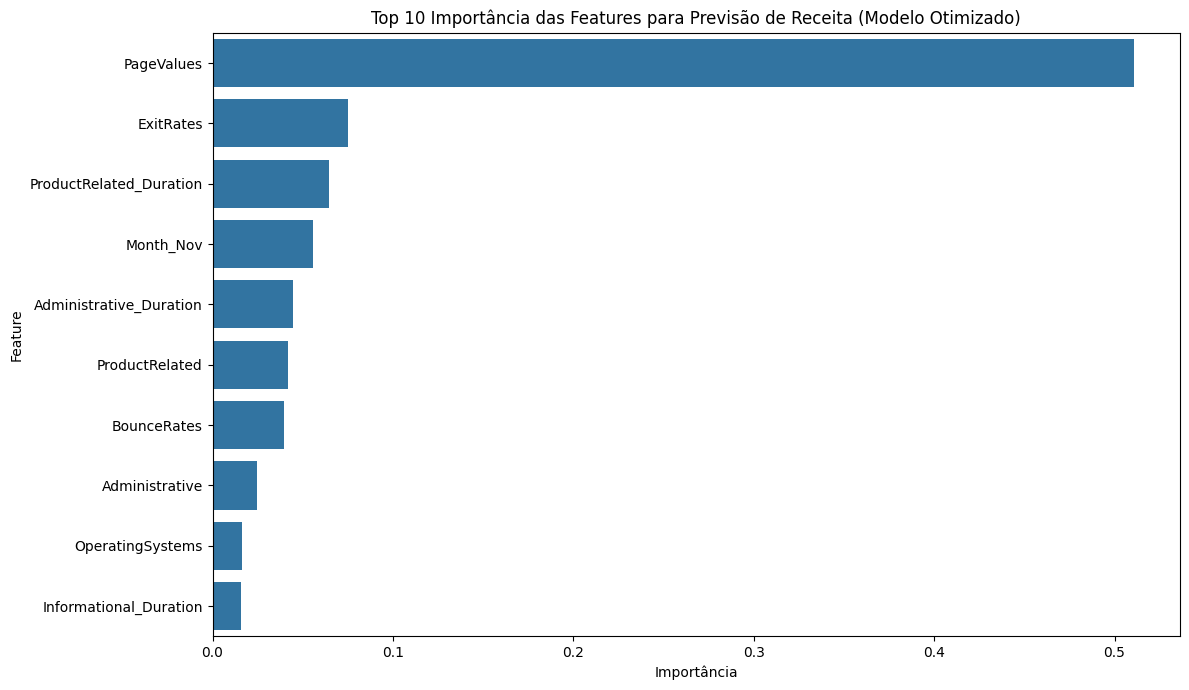

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a importância das features do melhor modelo
importances_optimized = best_rf_model.feature_importances_
feature_names_optimized = X_train.columns # As features são as mesmas usadas no treinamento

# Criar um DataFrame para visualização
feature_importance_df_optimized = pd.DataFrame({
    'Feature': feature_names_optimized,
    'Importance': importances_optimized
})

# Ordenar as features pela importância
feature_importance_df_optimized = feature_importance_df_optimized.sort_values(by='Importance', ascending=False)

print("Top 10 Features por Importância (Modelo Otimizado):")
display(feature_importance_df_optimized.head(10))

# Visualizar a importância das features
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_optimized.head(10))
plt.title('Top 10 Importância das Features para Previsão de Receita (Modelo Otimizado)')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Construção do Dendrograma**

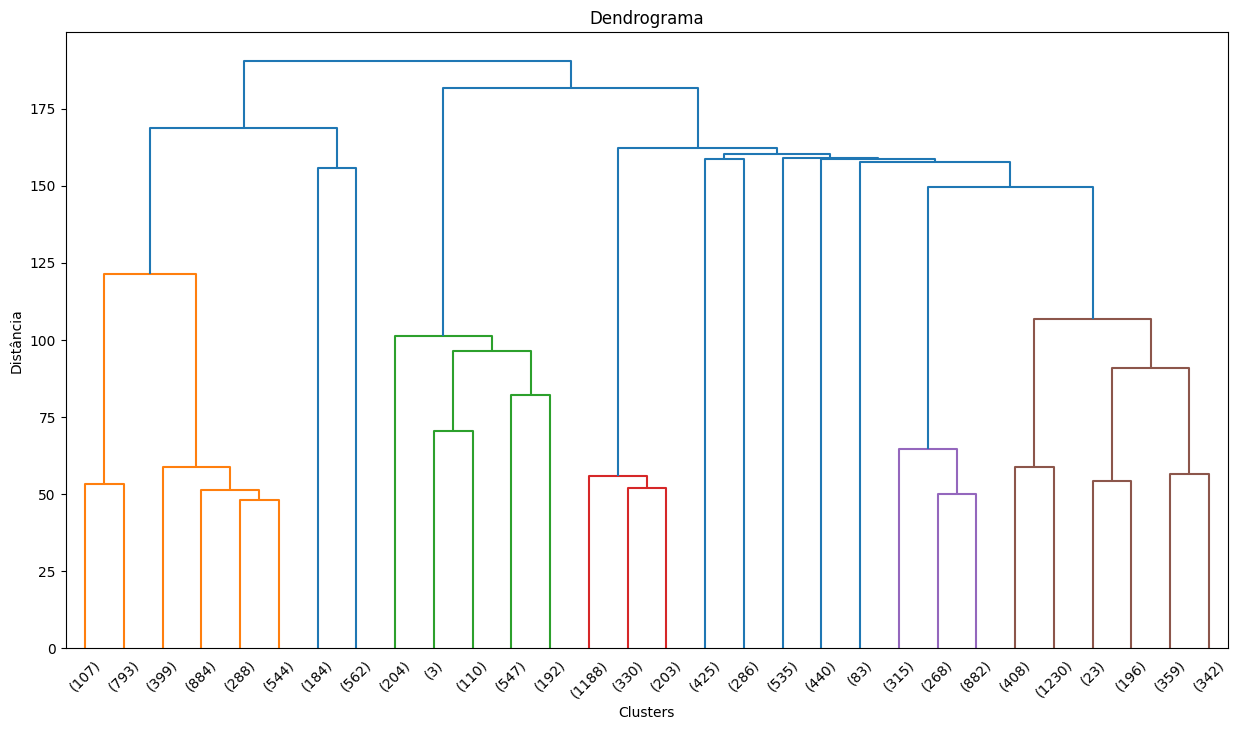

In [32]:
from scipy.cluster.hierarchy import linkage, dendrogram

plt.figure(figsize=(15,8))

linkage_data = linkage(
    X_scaled,
    method='ward'
)

dendrogram(
    linkage_data,
    truncate_mode='lastp',
    p=30
)

plt.title('Dendrograma')
plt.xlabel('Clusters')
plt.ylabel('Distância')

plt.show()

**Clusterização Hierárquica com 3 e 4 Grupos**

**Perfil dos Clusters**

In [34]:
display(
    df.groupby('Cluster_3')[
        [
            'Administrative',
            'ProductRelated',
            'BounceRates',
            'ExitRates',
            'PageValues'
        ]
    ].mean()
)

display(
    df.groupby('Cluster_4')[
        [
            'Administrative',
            'ProductRelated',
            'BounceRates',
            'ExitRates',
            'PageValues'
        ]
    ].mean()
)

,Administrative,ProductRelated,BounceRates,ExitRates,PageValues
Cluster_3,,,,,
0,1.446158,22.672693,0.047473,0.068334,3.292910
1,2.141355,25.851324,0.011745,0.033636,6.827398
2,6.646780,105.829545,0.006472,0.020243,8.461811


,Administrative,ProductRelated,BounceRates,ExitRates,PageValues
Cluster_4,,,,,
0,2.141355,25.851324,0.011745,0.033636,6.827398
1,0.151475,3.776139,0.161679,0.168574,0.219607
2,6.646780,105.829545,0.006472,0.020243,8.461811
3,1.766501,27.348259,0.019215,0.043532,4.053336


**Avaliação da Conversão (Revenue)**

In [35]:
display(
    pd.crosstab(
        df['Cluster_3'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

display(
    pd.crosstab(
        df['Cluster_4'],
        df['Revenue'],
        normalize='index'
    ) * 100
)

Revenue,False,True
Cluster_3,,
0,92.182930,7.817070
1,83.375482,16.624518
2,65.435606,34.564394


Revenue,False,True
Cluster_4,,
0,83.375482,16.624518
1,99.329759,0.670241
2,65.435606,34.564394
3,90.414594,9.585406


**Visualização dos Grupos**

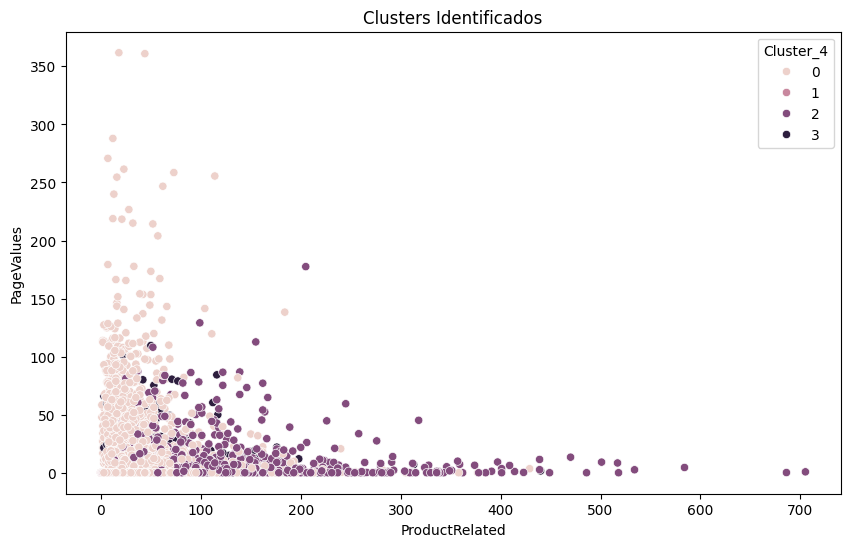

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='ProductRelated',
    y='PageValues',
    hue='Cluster_4'
)

plt.title('Clusters Identificados')

plt.show()

**Conclusão da Análise**

A análise de agrupamento hierárquico permitiu identificar diferentes perfis de usuários com base no comportamento de navegação no site. Foram avaliadas soluções com 3 e 4 grupos, sendo que a divisão em 4 clusters apresentou uma segmentação mais detalhada e útil para interpretação dos resultados.

Observou-se que os usuários com maior número de páginas de produtos visitadas, maior tempo de permanência no site e maiores valores de PageValues apresentaram maior probabilidade de realizar compras. Por outro lado, os grupos com maiores taxas de Bounce Rate e Exit Rate demonstraram menor intenção de compra.

Os resultados mostram que o comportamento de navegação é um forte indicativo da intenção de compra dos usuários. Essas informações podem ser utilizadas para direcionar campanhas de marketing, personalizar ofertas e identificar clientes com maior potencial de conversão.

###**Estatísticas Descritivas dos Clusters**
Analisando as estatísticas descritivas (média, desvio padrão, mínimo, máximo, etc.) de todas as variáveis numéricas para cada cluster. Para ver melhor o perfil quantitativo de cada grupo.

In [66]:
print('Estatísticas Descritivas por Cluster - 3 Grupos:')
display(df.groupby('Cluster_3').describe())

print('\nEstatísticas Descritivas por Cluster - 4 Grupos:')
display(df.groupby('Cluster_4').describe())

Estatísticas Descritivas por Cluster - 3 Grupos:


Administrative                                                 \
                   count      mean       std  min  25%  50%   75%   max   
Cluster_3                                                                 
0                 3761.0  1.446158  2.516929  0.0  0.0  0.0   2.0  16.0   
1                 7513.0  2.141355  2.908982  0.0  0.0  1.0   3.0  24.0   
2                 1056.0  6.646780  4.942633  0.0  3.0  6.0  10.0  27.0   

          Administrative_Duration              ... Cluster_4       \
                            count        mean  ...       75%  max   
Cluster_3                                      ...                  
0                          3761.0   40.495704  ...       3.0  3.0   
1                          7513.0   67.005678  ...       0.0  0.0   
2                          1056.0  322.704038  ...       2.0  2.0   

          Weekend_Numeric                                               
                    count      mean       std  min  25%  50%  75%  max  
Cluster_3                                                               
0                  3761.0  0.198352  0.398811  0.0  0.0  0.0  0.0  1.0  
1                  7513.0  0.240650  0.427506  0.0  0.0  0.0  0.0  1.0  
2                  1056.0  0.297348  0.457308  0.0  0.0  0.0  1.0  1.0  

[3 rows x 144 columns]


Estatísticas Descritivas por Cluster - 4 Grupos:


Administrative                                                 \
                   count      mean       std  min  25%  50%   75%   max   
Cluster_4                                                                 
0                 7513.0  2.141355  2.908982  0.0  0.0  1.0   3.0  24.0   
1                  746.0  0.151475  0.833754  0.0  0.0  0.0   0.0  12.0   
2                 1056.0  6.646780  4.942633  0.0  3.0  6.0  10.0  27.0   
3                 3015.0  1.766501  2.685804  0.0  0.0  0.0   3.0  16.0   

          Administrative_Duration              ... Cluster_3       \
                            count        mean  ...       75%  max   
Cluster_4                                      ...                  
0                          7513.0   67.005678  ...       1.0  1.0   
1                           746.0    4.161562  ...       0.0  0.0   
2                          1056.0  322.704038  ...       2.0  2.0   
3                          3015.0   49.485844  ...       0.0  0.0   

          Weekend_Numeric                                               
                    count      mean       std  min  25%  50%  75%  max  
Cluster_4                                                               
0                  7513.0  0.240650  0.427506  0.0  0.0  0.0  0.0  1.0  
1                   746.0  0.170241  0.376097  0.0  0.0  0.0  0.0  1.0  
2                  1056.0  0.297348  0.457308  0.0  0.0  0.0  1.0  1.0  
3                  3015.0  0.205307  0.403993  0.0  0.0  0.0  0.0  1.0  

[4 rows x 144 columns]

### **Comparação da Média de PageValues por Cluster**

Aqui temos a média de PageValues para cada cluster, o que pode indicar o nível de engajamento e o valor das páginas visitadas em cada grupo.

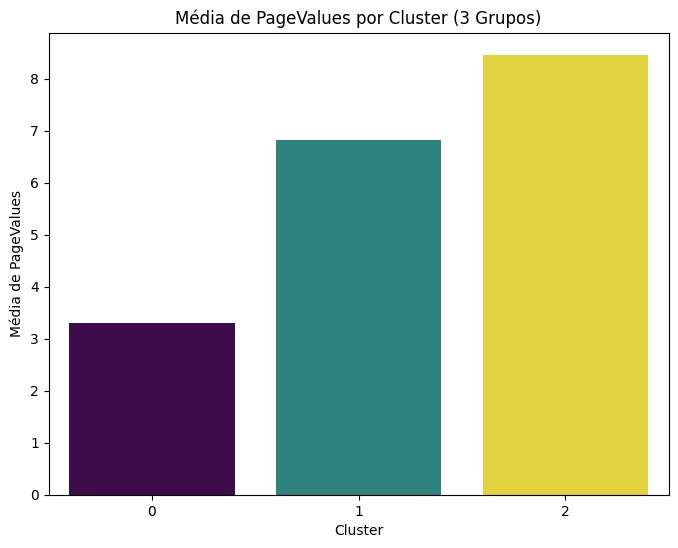

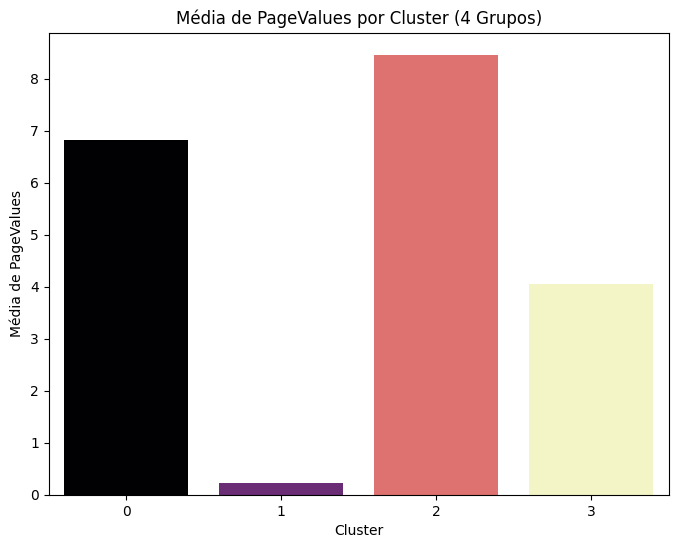

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a média de PageValues para cada cluster (3 clusters)
page_values_mean_3 = df.groupby('Cluster_3')['PageValues'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster_3', y='PageValues', data=page_values_mean_3, palette='viridis', hue='Cluster_3', legend=False)
plt.title('Média de PageValues por Cluster (3 Grupos)')
plt.xlabel('Cluster')
plt.ylabel('Média de PageValues')
plt.show()

# Calcular a média de PageValues para cada cluster (4 clusters)
page_values_mean_4 = df.groupby('Cluster_4')['PageValues'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster_4', y='PageValues', data=page_values_mean_4, palette='magma', hue='Cluster_4', legend=False)
plt.title('Média de PageValues por Cluster (4 Grupos)')
plt.xlabel('Cluster')
plt.ylabel('Média de PageValues')
plt.show()

### Comparação da Média de BounceRates por Cluster

In [69]:
print('Média de BounceRates por grupo - 3 clusters')
display(
    df.groupby('Cluster_3')['BounceRates'].mean()
)

print('Média de BounceRates por grupo - 4 clusters')
display(
    df.groupby('Cluster_4')['BounceRates'].mean()
)

Média de BounceRates por grupo - 3 clusters


,BounceRates
Cluster_3,
0,0.047473
1,0.011745
2,0.006472


Média de BounceRates por grupo - 4 clusters


,BounceRates
Cluster_4,
0,0.011745
1,0.161679
2,0.006472
3,0.019215


In [70]:
print('Correlação entre BounceRates e PageValues por grupo - 3 clusters')
display(
    df.groupby('Cluster_3')[['BounceRates', 'PageValues']].corr().unstack().iloc[:, 1]
)


Correlação entre BounceRates e PageValues por grupo - 3 clusters


,BounceRates
,PageValues
Cluster_3,
0,-0.181480
1,-0.097255
2,-0.139566


In [71]:
print('Correlação entre BounceRates e PageValues por grupo - 4 clusters')
display(
    df.groupby('Cluster_4')[['BounceRates', 'PageValues']].corr().unstack().iloc[:, 1]
)


Correlação entre BounceRates e PageValues por grupo - 4 clusters


,BounceRates
,PageValues
Cluster_4,
0,-0.097255
1,-0.151614
2,-0.139566
3,-0.142061


### Gráfico de Dispersão: BounceRates vs PageValues por Cluster

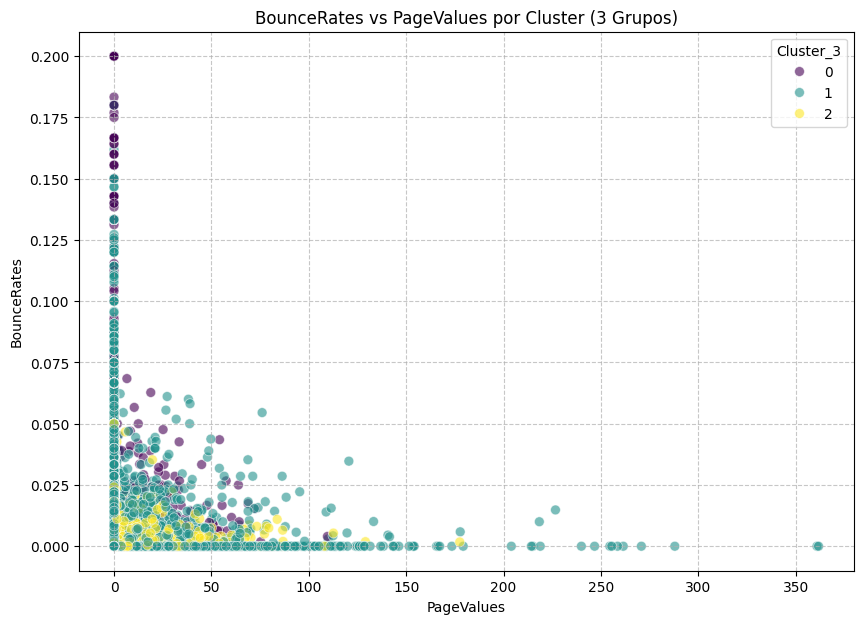

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de Dispersão para 3 Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='PageValues',
    y='BounceRates',
    hue='Cluster_3',
    palette='viridis',
    s=50, # Tamanho dos pontos
    alpha=0.6 # Transparência
)
plt.title('BounceRates vs PageValues por Cluster (3 Grupos)')
plt.xlabel('PageValues')
plt.ylabel('BounceRates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

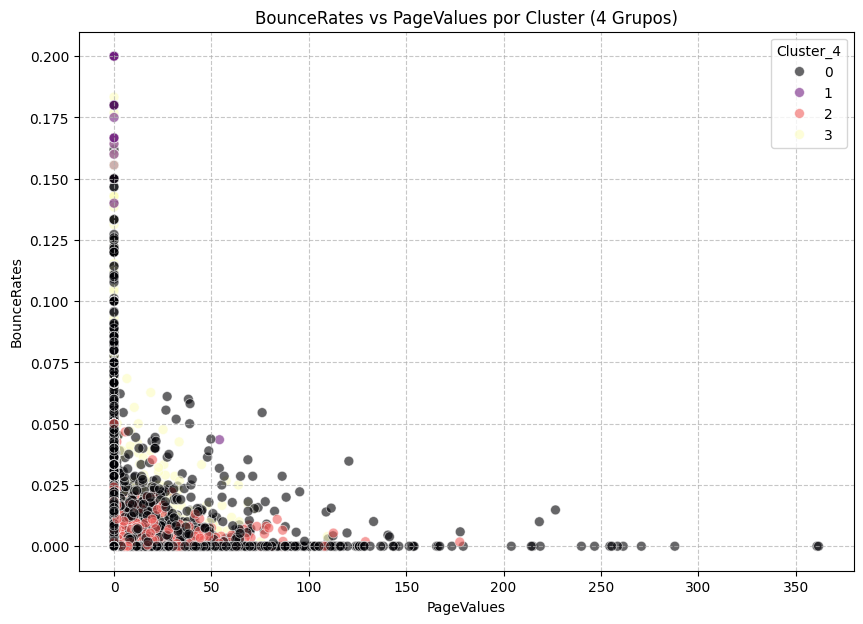

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de Dispersão para 4 Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='PageValues',
    y='BounceRates',
    hue='Cluster_4',
    palette='magma',
    s=50, # Tamanho dos pontos
    alpha=0.6 # Transparência
)
plt.title('BounceRates vs PageValues por Cluster (4 Grupos)')
plt.xlabel('PageValues')
plt.ylabel('BounceRates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

###**Distribuição da Variável Revenue por Cluster dos 4 Grupos**

Visualização da proporção de usuários que geraram receita (realizaram uma compra) dentro de cada um dos 4 clusters. Isso ajudará a entender qual cluster tem a maior ou menor propensão à compra.

In [75]:
conversion_rate_per_cluster = df.groupby('Cluster_4')['Revenue_Numeric'].mean() * 100
print('Taxa de Conversão (Percentual de Compras) por Cluster (4 Grupos):')
display(conversion_rate_per_cluster)

Taxa de Conversão (Percentual de Compras) por Cluster (4 Grupos):


,Revenue_Numeric
Cluster_4,
0,16.624518
1,0.670241
2,34.564394
3,9.585406


###**Top 10 Importância das Features (Modelo Otimizado) para Prever Compra**

Esta visualização mostra as variáveis mais importantes que o modelo otimizado considerou para prever a intenção de compra (Revenue) em todo o conjunto de dados.

In [78]:
import pandas as pd

# Make a copy of df to avoid modifying the global df for this specific calculation
df_analysis = df.copy()

# Apply one-hot encoding to 'Month' and 'VisitorType' in this temporary DataFrame
# This ensures that columns like 'Month_Nov' are present for the grouping operation.
df_analysis = pd.get_dummies(df_analysis, columns=['Month', 'VisitorType'], drop_first=True)

# The list of top 10 features is already available from previous execution
# top_10_features = feature_importance_df_optimized['Feature'].head(10).tolist()

# Calculate the mean of these top 10 features for each of the 4 clusters
# Now df_analysis should contain 'Month_Nov' and 'Cluster_4'
mean_top_features_per_cluster = df_analysis.groupby('Cluster_4')[top_10_features].mean()

print('\nMédia das 10 Variáveis Mais Importantes por Cluster (4 Grupos):')
display(mean_top_features_per_cluster)


Média das 10 Variáveis Mais Importantes por Cluster (4 Grupos):


,PageValues,ExitRates,ProductRelated_Duration,Month_Nov,Administrative_Duration,ProductRelated,BounceRates,Administrative,OperatingSystems,Informational_Duration
Cluster_4,,,,,,,,,,
0,6.827398,0.033636,956.037303,0.282444,67.005678,25.851324,0.011745,2.141355,2.133768,15.779847
1,0.219607,0.168574,121.151937,0.199732,4.161562,3.776139,0.161679,0.151475,2.053619,0.588472
2,8.461811,0.020243,4301.948008,0.688447,322.704038,105.829545,0.006472,6.646780,2.085227,250.012267
3,4.053336,0.043532,966.924112,0.000000,49.485844,27.348259,0.019215,1.766501,2.130680,13.943191


###**Gráfico Comparativo da Média de 'PageValues' por Cluster (4 Grupos)**
Este gráfico mostra a média de PageValues para cada um dos 4 clusters, permitindo uma comparação direta do nível de engajamento e valor das páginas visitadas em cada grupo.

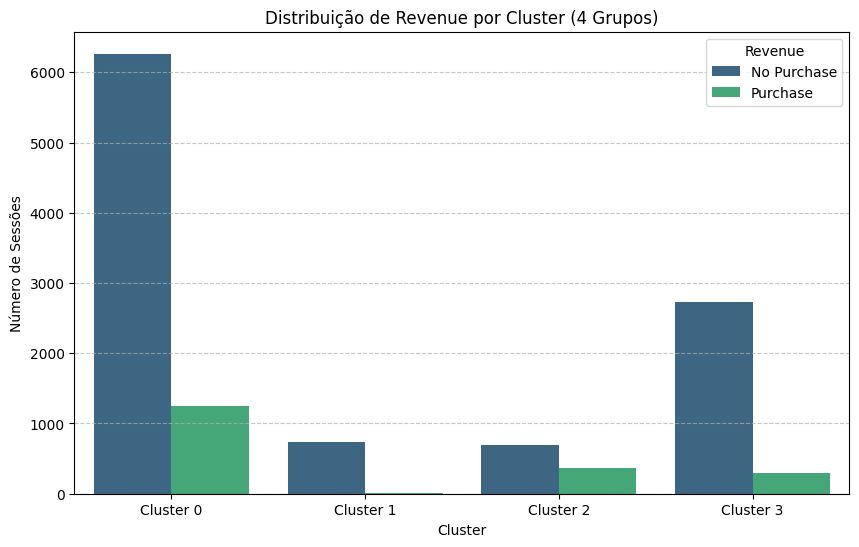

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Cluster_4', hue='Revenue_Numeric', palette='viridis')
plt.title('Distribuição de Revenue por Cluster (4 Grupos)')
plt.xlabel('Cluster')
plt.ylabel('Número de Sessões')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'])
plt.legend(title='Revenue', labels=['No Purchase', 'Purchase'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [80]:
from sklearn.metrics import silhouette_score

# Calcular o Silhouette Score para a solução de 4 clusters
silhouette_avg = silhouette_score(X_scaled, df['Cluster_4'])

print(f"O Silhouette Score para 4 clusters é: {silhouette_avg:.4f}")

O Silhouette Score para 4 clusters é: 0.0747


### Visualização dos Clusters com PCA (2D)

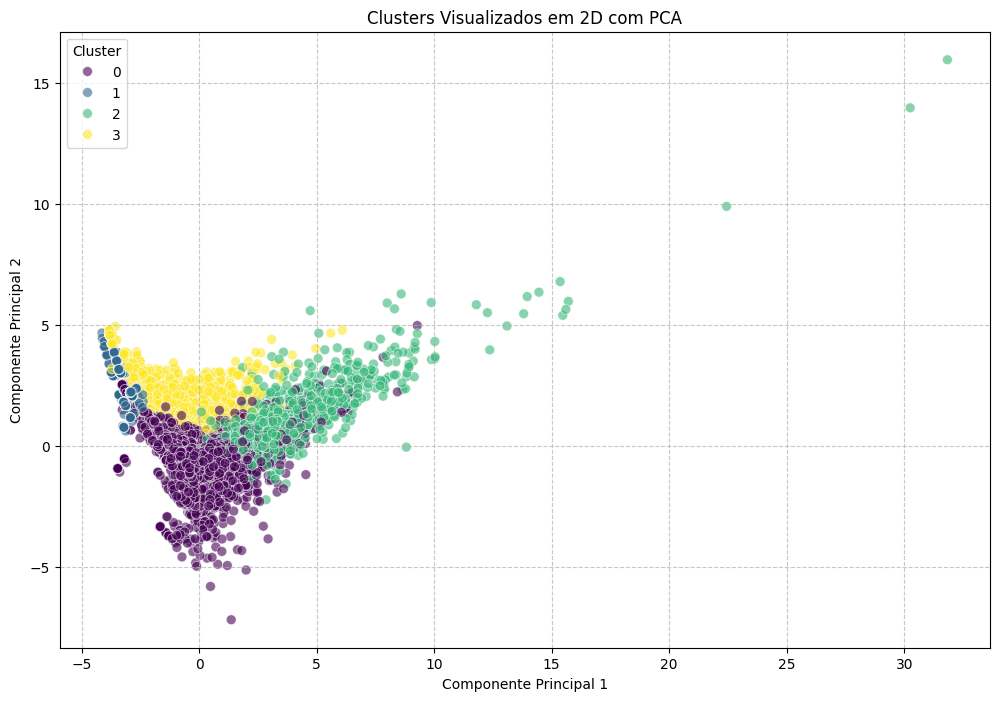

In [81]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aplicar PCA para reduzir os dados a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criar um DataFrame com os componentes PCA e os rótulos de cluster
pca_df = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
pca_df['Cluster'] = df['Cluster_4'] # Usamos Cluster_4 para a visualização

# Plotar o gráfico de dispersão
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=50, # Tamanho dos pontos
    alpha=0.6 # Transparência
)
plt.title('Clusters Visualizados em 2D com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.show()

### Comparação com Agrupamento K-Means

In [82]:
from sklearn.cluster import KMeans

# Aplicar K-Means com 4 clusters
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init para evitar inicializações ruins
df['Cluster_KMeans_4'] = kmeans_model.fit_predict(X_scaled)

print('Distribuição dos grupos (4 clusters K-Means)')
display(df['Cluster_KMeans_4'].value_counts())

Distribuição dos grupos (4 clusters K-Means)


,count
Cluster_KMeans_4,
3,5502
0,3169
2,2393
1,1266


In [83]:
from sklearn.metrics import silhouette_score

# Calcular o Silhouette Score para a solução de 4 clusters do K-Means
silhouette_avg_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans_4'])

print(f"O Silhouette Score para 4 clusters (K-Means) é: {silhouette_avg_kmeans:.4f}")
print(f"O Silhouette Score para 4 clusters (Hierárquico) foi: {silhouette_avg:.4f}")

O Silhouette Score para 4 clusters (K-Means) é: 0.1260
O Silhouette Score para 4 clusters (Hierárquico) foi: 0.0747


### Visualização dos Clusters K-Means com PCA (2D)

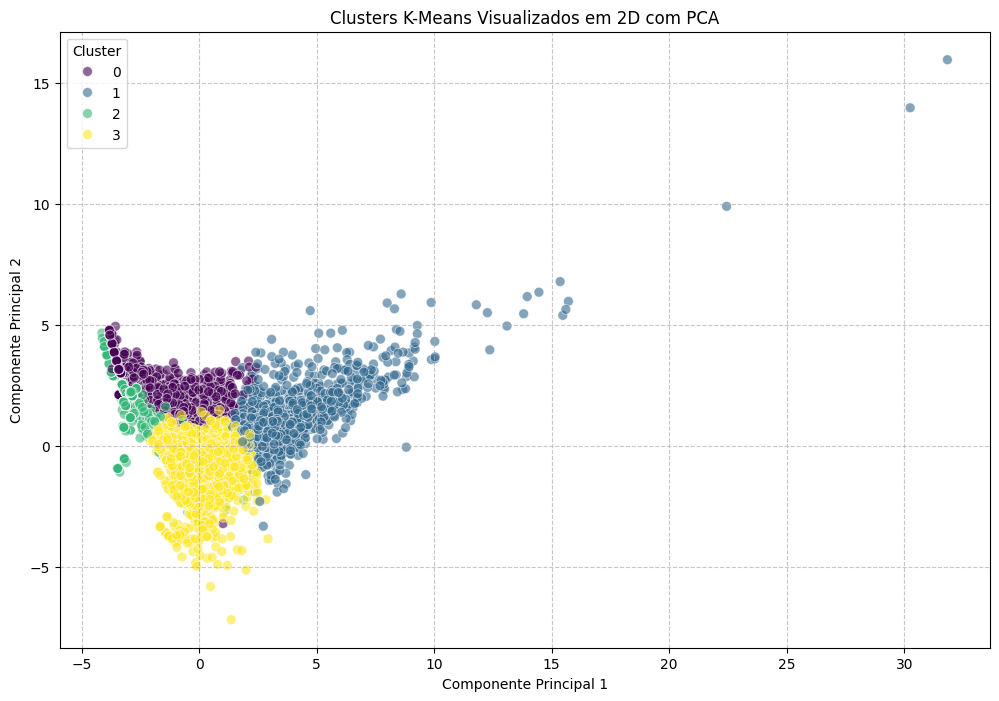

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reutilizando X_pca do cálculo anterior, já reduzido a 2 componentes
# Adicionar os rótulos de cluster do K-Means ao DataFrame PCA
pca_df_kmeans = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
pca_df_kmeans['Cluster'] = df['Cluster_KMeans_4'] # Usamos Cluster_KMeans_4 para a visualização

# Plotar o gráfico de dispersão para os clusters K-Means
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal_Component_1',
    y='Principal_Component_2',
    hue='Cluster',
    palette='viridis',
    data=pca_df_kmeans,
    s=50, # Tamanho dos pontos
    alpha=0.6 # Transparência
)
plt.title('Clusters K-Means Visualizados em 2D com PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.show()

### Análise Detalhada dos Perfis dos Clusters

#### Perfil dos Clusters Hierárquicos (4 Grupos)

In [87]:
import pandas as pd

# Numéricas relevantes do vars_cluster
numerical_features_for_profile = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print('Média das Features Numéricas por Cluster Hierárquico (4 Grupos):')
display(df.groupby('Cluster_4')[numerical_features_for_profile].mean())

print('\nDistribuição de Meses por Cluster Hierárquico (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_4'], df['Month'], normalize='index') * 100)

print('\nDistribuição de Tipo de Visitante por Cluster Hierárquico (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_4'], df['VisitorType'], normalize='index') * 100)

print('\nDistribuição de Fim de Semana por Cluster Hierárquico (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_4'], df['Weekend'], normalize='index') * 100)

Média das Features Numéricas por Cluster Hierárquico (4 Grupos):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Cluster_4,,,,,,,,,,
0,2.141355,67.005678,0.347797,15.779847,25.851324,956.037303,0.011745,0.033636,6.827398,0.003328
1,0.151475,4.161562,0.028150,0.588472,3.776139,121.151937,0.161679,0.168574,0.219607,0.067024
2,6.646780,322.704038,2.428030,250.012267,105.829545,4301.948008,0.006472,0.020243,8.461811,0.007197
3,1.766501,49.485844,0.335323,13.943191,27.348259,966.924112,0.019215,0.043532,4.053336,0.223814



Distribuição de Meses por Cluster Hierárquico (4 Grupos) (%):


Month,Aug,Dec,Feb,Jul,June,Mar,May,Nov,Oct,Sep
Cluster_4,,,,,,,,,,
0,1.118062,21.030214,0.000000,5.656861,3.833356,22.946892,4.152802,28.244376,7.134301,5.883136
1,1.876676,12.332440,24.664879,0.000000,0.000000,17.694370,23.458445,19.973190,0.000000,0.000000
2,4.450758,5.208333,0.000000,0.662879,0.000000,4.829545,14.204545,68.844697,1.231061,0.568182
3,9.552239,0.000000,0.000000,0.000000,0.000000,0.000000,90.447761,0.000000,0.000000,0.000000



Distribuição de Tipo de Visitante por Cluster Hierárquico (4 Grupos) (%):


VisitorType,New_Visitor,Other,Returning_Visitor
Cluster_4,,,
0,21.735658,1.131372,77.132970
1,3.351206,0.000000,96.648794
2,2.556818,0.000000,97.443182
3,0.298507,0.000000,99.701493



Distribuição de Fim de Semana por Cluster Hierárquico (4 Grupos) (%):


Weekend,0,1
Cluster_4,,
0,75.935046,24.064954
1,82.975871,17.024129
2,70.265152,29.734848
3,79.469320,20.530680


#### Perfil dos Clusters K-Means (4 Grupos)

In [88]:
import pandas as pd

# Reutilizando as features numéricas definidas anteriormente

print('Média das Features Numéricas por Cluster K-Means (4 Grupos):')
display(df.groupby('Cluster_KMeans_4')[numerical_features_for_profile].mean())

print('\nDistribuição de Meses por Cluster K-Means (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_KMeans_4'], df['Month'], normalize='index') * 100)

print('\nDistribuição de Tipo de Visitante por Cluster K-Means (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_KMeans_4'], df['VisitorType'], normalize='index') * 100)

print('\nDistribuição de Fim de Semana por Cluster K-Means (4 Grupos) (%):')
display(pd.crosstab(df['Cluster_KMeans_4'], df['Weekend'], normalize='index') * 100)

Média das Features Numéricas por Cluster K-Means (4 Grupos):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Cluster_KMeans_4,,,,,,,,,,
0,1.572736,49.692151,0.254023,10.525335,22.680341,812.686474,0.028106,0.050674,5.170816,0.218681
1,7.631912,326.811703,2.783570,250.471197,108.654818,4322.720804,0.006209,0.019411,9.504347,0.018483
2,1.199331,37.294995,0.183034,9.293085,14.216047,552.982077,0.051777,0.072936,2.684390,0.017133
3,2.004726,61.073882,0.262087,9.515629,26.862777,974.185171,0.009595,0.031151,6.865137,0.000000



Distribuição de Meses por Cluster K-Means (4 Grupos) (%):


Month,Aug,Dec,Feb,Jul,June,Mar,May,Nov,Oct,Sep
Cluster_KMeans_4,,,,,,,,,,
0,0.000000,0.000000,0.063111,0.000000,0.000000,0.000000,99.936889,0.000000,0.000000,0.000000
1,4.581359,11.374408,0.157978,3.554502,2.290679,8.451817,15.560821,45.576619,4.818325,3.633491
2,1.504388,4.638529,7.521939,1.379022,1.713331,75.177601,0.000000,7.271208,0.417885,0.376097
3,6.161396,26.753908,0.000000,6.434024,3.962196,0.018175,0.000000,40.839695,8.687750,7.142857



Distribuição de Tipo de Visitante por Cluster K-Means (4 Grupos) (%):


VisitorType,New_Visitor,Other,Returning_Visitor
Cluster_KMeans_4,,,
0,9.813821,0.000000,90.186179
1,3.396524,0.236967,96.366509
2,10.238195,0.668617,89.093188
3,19.901854,1.199564,78.898582



Distribuição de Fim de Semana por Cluster K-Means (4 Grupos) (%):


Weekend,0,1
Cluster_KMeans_4,,
0,79.047018,20.952982
1,73.538705,26.461295
2,76.681989,23.318011
3,76.172301,23.827699


**Conclusão**


A análise mostrou que o comportamento de navegação dos usuários é um forte indicador da intenção de compra. Usuários mais engajados, que visitam mais páginas de produtos, permanecem mais tempo no site e apresentam maiores valores de PageValues, têm maior probabilidade de realizar compras. Por outro lado, altas taxas de Bounce Rate e Exit Rate estão associadas a uma menor chance de conversão.

A clusterização permitiu identificar diferentes perfis de usuários e revelou a influência de fatores sazonais, como meses específicos e datas promocionais, no comportamento de compra. Esses insights podem ser utilizados para melhorar a segmentação de clientes, personalizar campanhas de marketing e aumentar a eficiência das estratégias de vendas no e-commerce.